In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

# image path
workpath = '/content/drive/MyDrive/DigitalImageProcessing/'


/usr/local/lib/python3.11/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


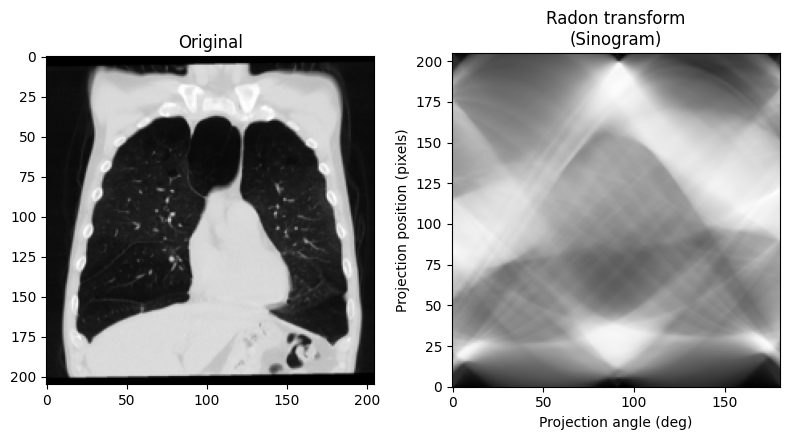

In [ ]:
# Radon transform to create sinograms of an image. Here we use the Phantom Head
#image = shepp_logan_phantom()
import cv2

image=cv2.imread(workpath + 'Data/lung.png', cv2.IMREAD_GRAYSCALE)

image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)
image = image[:, 5:-6] # change the shape to 205x205

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))
ax1.set_title("Original")
ax1.imshow(image, cmap=plt.cm.Greys_r)
#theta = np.linspace(0.0, 180.0, 60, endpoint=False)
theta = np.linspace(0.0, 180.0, max(image.shape), endpoint=False)
sinogram = radon(image, theta=theta)

#dx, dy = 0.5 * 180.0 /60, 0.5 / sinogram.shape[0]
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax2.set_title("Radon transform\n(Sinogram)")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)

fig.tight_layout()
plt.show()

FBP rms reconstruction error: 0.168


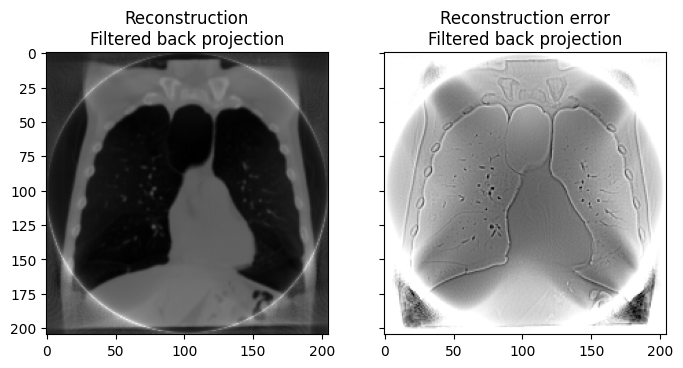

In [ ]:
# Filtered Back-Projection Image reconstruction

from skimage.transform import iradon

reconstruction_fbp = iradon(sinogram, theta=theta, circle=False, filter_name='shepp-logan', output_size=image.shape[0])

error = reconstruction_fbp - image
print(f'FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}')

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5), sharex=True, sharey=True)
ax1.set_title("Reconstruction\nFiltered back projection")
ax1.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax2.set_title("Reconstruction error\nFiltered back projection")
ax2.imshow(reconstruction_fbp - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()

SART (1 iteration) rms reconstruction error: 0.305
SART (2 iterations) rms reconstruction error: 0.31
SART (3 iterations) rms reconstruction error: 0.314


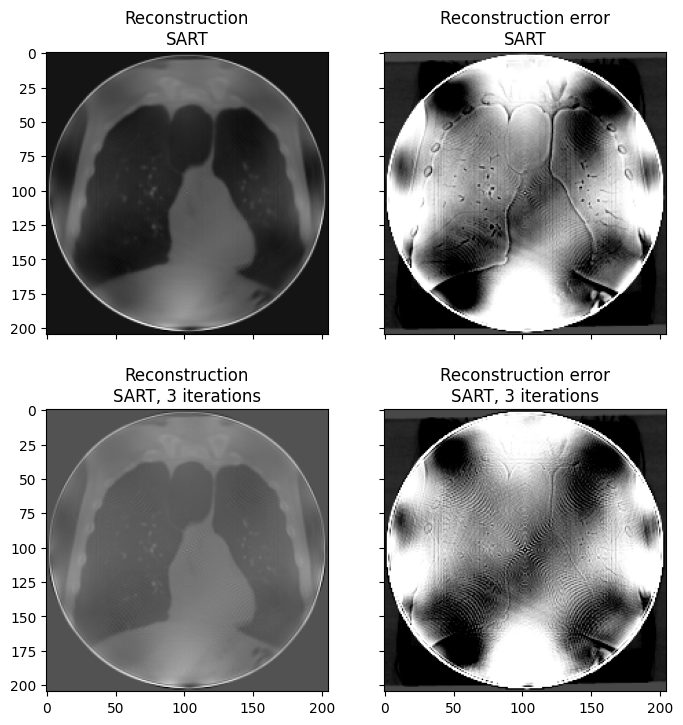

In [ ]:
# ART Image Reconstruction from Sinograms

from skimage.transform import iradon_sart

reconstruction_sart = iradon_sart(sinogram, theta=theta)
error = reconstruction_sart - image
print(
    f'SART (1 iteration) rms reconstruction error: ' f'{np.sqrt(np.mean(error**2)):.3g}'
)

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, axes = plt.subplots(2, 2, figsize=(8, 8.5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title("Reconstruction\nSART")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nSART")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart)
error = reconstruction_sart2 - image
print(
    f'SART (2 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)


# Run a third iteration of SART by supplying the reconstruction
# from the second iteration as an initial estimate
reconstruction_sart3 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart2)
error = reconstruction_sart3 - image
print(
    f'SART (3 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[2].set_title("Reconstruction\nSART, 3 iterations")
ax[2].imshow(reconstruction_sart3, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nSART, 3 iterations")
ax[3].imshow(reconstruction_sart3 - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()